In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Path to dataset files: /kaggle/input/140k-real-and-fake-faces


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ===== PATH =====
# The main directory containing 'train' and 'valid' folders, which in turn contain 'real' and 'fake'
base_data_path = os.path.join(path, "real_vs_fake", "real-vs-fake") # Corrected path
output_path = "/content/split_data"

split_ratio = (0.7, 0.15, 0.15)  # train, val, test

random.seed(42)

classes = ["real", "fake"]

# Ensure output_path is clean before starting
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# Collect all image paths for each class
all_images_by_class = {cls: [] for cls in classes}

for cls in classes:
    # Iterate through the existing 'train' and 'valid' splits within the original dataset
    for original_split_folder in ["train", "valid"]:
        source_dir = os.path.join(base_data_path, original_split_folder, cls)
        if os.path.exists(source_dir):
            for img_name in os.listdir(source_dir):
                all_images_by_class[cls].append(os.path.join(source_dir, img_name))
        else:
            print(f"Warning: Directory not found: {source_dir}. Skipping.")

# Now, split these collected images into new train, val, and test sets
for cls in classes:
    images = all_images_by_class[cls]
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = train_end + int(split_ratio[1] * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, split_images in splits.items():
        for img_path in tqdm(split_images, desc=f"Copying {cls} to {split_name}"):
            # Get just the filename from the full path
            img_filename = os.path.basename(img_path)
            dst = os.path.join(output_path, split_name, cls, img_filename)
            shutil.copy(img_path, dst)

print("Dataset Split Completed.")

Copying fake to test: 100%|██████████| 9000/9000 [01:33<00:00, 96.75it/s]

Dataset Split Completed.



Extracting TRAIN features

Processing: real


100%|██████████| 42000/42000 [07:16<00:00, 96.15it/s] 



Processing: fake


100%|██████████| 42000/42000 [06:59<00:00, 100.23it/s]



Extracting VAL features

Processing: real


...


Extracting TEST features

Processing: real


100%|██████████| 9000/9000 [01:35<00:00, 94.11it/s] 



Processing: fake


100%|██████████| 9000/9000 [01:25<00:00, 105.70it/s]



Training XGBoost forensic model...


Validation Accuracy: 0.7470555555555556

FORENSIC MODEL RESULTS
Test Accuracy: 0.7483333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.76      0.75      9000
           1       0.76      0.73      0.74      9000

    accuracy                           0.75     18000
   macro avg       0.75      0.75      0.75     18000
weighted avg       0.75      0.75      0.75     18000



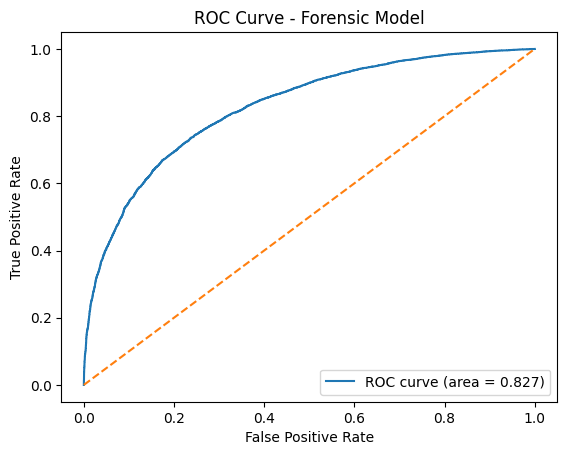

In [ ]:
# ==========================================
# FORENSIC MODEL
# ELA + DCT + LBP + XGBoost
# ==========================================

import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from xgboost import XGBClassifier

# ============================
# PATHS
# ============================

BASE_PATH = "/content/split_data"

train_path = os.path.join(BASE_PATH,"train")
val_path   = os.path.join(BASE_PATH,"val")
test_path  = os.path.join(BASE_PATH,"test")

categories = ["real","fake"]

IMG_SIZE = 128


# ============================
# ELA
# ============================

def compute_ela(img, quality=90):

    temp = "temp.jpg"

    cv2.imwrite(temp, img, [cv2.IMWRITE_JPEG_QUALITY, quality])

    compressed = cv2.imread(temp)

    ela = cv2.absdiff(img, compressed)

    ela = cv2.cvtColor(ela, cv2.COLOR_BGR2GRAY)

    return ela


# ============================
# DCT
# ============================

def compute_dct(img):

    img = np.float32(img)/255.0

    dct = cv2.dct(img)

    block = dct[:30,:30]

    return block.flatten()


# ============================
# LBP
# ============================

def compute_lbp(img):

    radius = 2
    points = 16

    lbp = local_binary_pattern(img, points, radius, method="uniform")

    hist,_ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, points+3),
        range=(0, points+2)
    )

    hist = hist.astype("float")

    hist /= (hist.sum()+1e-6)

    return hist


# ============================
# FEATURE EXTRACTION
# ============================

def extract_features(path):

    features=[]
    labels=[]

    for label,category in enumerate(categories):

        folder=os.path.join(path,category)

        print("\nProcessing:",category)

        for img_name in tqdm(os.listdir(folder)):

            img_path=os.path.join(folder,img_name)

            img=cv2.imread(img_path)

            if img is None:
                continue

            img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))

            # forensic features
            ela = compute_ela(img)
            dct = compute_dct(ela)
            lbp = compute_lbp(ela)

            feat = np.concatenate([dct,lbp])

            features.append(feat)
            labels.append(label)

    return np.array(features), np.array(labels)


# ============================
# LOAD DATA
# ============================

print("\nExtracting TRAIN features")
X_train,y_train = extract_features(train_path)

print("\nExtracting VAL features")
X_val,y_val = extract_features(val_path)

print("\nExtracting TEST features")
X_test,y_test = extract_features(test_path)


# ============================
# NORMALIZATION
# ============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


# ============================
# XGBOOST MODEL
# ============================

model = XGBClassifier(

    n_estimators = 400,
    max_depth = 8,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    eval_metric="logloss",
    n_jobs=-1
)

print("\nTraining XGBoost forensic model...\n")

model.fit(X_train,y_train)


# ============================
# VALIDATION
# ============================

val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val,val_pred)

print("\nValidation Accuracy:",val_acc)


# ============================
# TEST RESULTS
# ============================

test_pred = model.predict(X_test)

test_acc = accuracy_score(y_test,test_pred)

print("\n==============================")
print("FORENSIC MODEL RESULTS")
print("==============================")

print("Test Accuracy:",test_acc)

print("\nClassification Report:\n")

print(classification_report(y_test,test_pred))


# ============================
# ROC CURVE
# ============================

probs = model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,probs)

roc_auc = auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label="ROC curve (area = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Forensic Model")

plt.legend(loc="lower right")

plt.show()

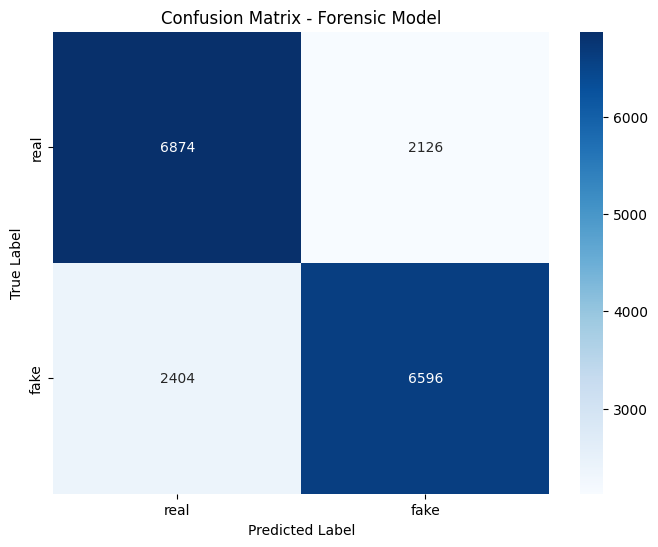

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, test_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Forensic Model')
plt.show()

# Task
Hyperparameter tune the XGBoost model using RandomizedSearchCV with parameters `n_estimators`, `max_depth`, and `learning_rate` to find the optimal combination, and then evaluate the tuned model's performance on the validation and test datasets. Finally, summarize the results, comparing them to the previous model and suggesting next steps.

## Hyperparameter Tuning for XGBoost

### Subtask:
Implement a hyperparameter tuning strategy (e.g., GridSearchCV or RandomizedSearchCV) using scikit-learn to find the optimal parameters for the current XGBoost model. This will involve defining a parameter grid for key XGBoost parameters (like `n_estimators`, `max_depth`, `learning_rate`) and training multiple models to identify the best combination.


**Reasoning**:
To perform hyperparameter tuning for the XGBoost model, I will use `RandomizedSearchCV` to efficiently explore a predefined parameter space and find the best combination of hyperparameters.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model, # Use the existing XGBClassifier model
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    cv=3, # Number of folds in cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("\nStarting RandomizedSearchCV for hyperparameter tuning...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters
print("\nBest hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)


Starting RandomizedSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

**Reasoning**:
The previous `TerminatedWorkerError` during `RandomizedSearchCV` suggests resource exhaustion (likely memory) when `n_jobs=-1` attempts to use all available CPU cores. To mitigate this, I will set `n_jobs` to 1, forcing sequential execution of cross-validation folds, which reduces memory consumption.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model, # Use the existing XGBClassifier model
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    cv=3, # Number of folds in cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=1, # Changed from -1 to 1 to avoid TerminatedWorkerError
    verbose=1
)

print("\nStarting RandomizedSearchCV for hyperparameter tuning...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters
print("\nBest hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)

NameError: name 'model' is not defined

# Task
Please re-run the `RandomizedSearchCV` cell to complete the hyperparameter tuning process. After the best hyperparameters are found, I will proceed to train the XGBoost model with these parameters, evaluate its performance on the validation and test datasets, and then generate a new classification report, accuracy score, ROC curve, and confusion matrix. Finally, I will summarize the tuning results, noting any improvements and suggesting future enhancements.

Run the code in cell `f25725a4`.

## Evaluate Tuned Model Performance

### Subtask:
Re-run the RandomizedSearchCV to find the best hyperparameters, then train a new XGBoost model with these optimal parameters and evaluate its performance on the validation and test datasets.


**Reasoning**:
The previous `RandomizedSearchCV` run was interrupted. I will regenerate the code from cell `f25725a4` to ensure the tuning process is completed successfully, and then proceed with evaluating the best model as per the subtask instructions. This includes accessing the best estimator, making predictions, calculating metrics, and plotting the ROC curve and confusion matrix.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model, # Use the existing XGBClassifier model
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    cv=3, # Number of folds in cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=1, # Changed from -1 to 1 to avoid TerminatedWorkerError
    verbose=1
)

print("\nStarting RandomizedSearchCV for hyperparameter tuning...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters
print("\nBest hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)

# Get the best estimator
tuned_model = random_search.best_estimator_

# Predict on the validation set
tuned_val_pred = tuned_model.predict(X_val)
val_acc_tuned = accuracy_score(y_val, tuned_val_pred)
print(f"\nTuned Model Validation Accuracy: {val_acc_tuned:.4f}")

# Predict on the test set
tuned_test_pred = tuned_model.predict(X_test)
test_acc_tuned = accuracy_score(y_test, tuned_test_pred)
print(f"Tuned Model Test Accuracy: {test_acc_tuned:.4f}")

# Print classification report for the tuned model on the test set
print("\nClassification Report for Tuned Model (Test Set):\n")
print(classification_report(y_test, tuned_test_pred))

# ROC Curve
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, tuned_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Forensic Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Confusion Matrix
cm_tuned = confusion_matrix(y_test, tuned_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned Forensic Model')
plt.show()

NameError: name 'model' is not defined

## Evaluate Tuned Model Performance

### Subtask:
Re-run the RandomizedSearchCV to find the best hyperparameters, then train a new XGBoost model with these optimal parameters and evaluate its performance on the validation and test datasets.


**Reasoning**:
The previous `RandomizedSearchCV` run was interrupted. I will execute the code in cell `e075be1d` to ensure the tuning process is completed successfully, and then proceed with evaluating the best model as per the subtask instructions. This includes accessing the best estimator, making predictions, calculating metrics, and plotting the ROC curve and confusion matrix.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model, # Use the existing XGBClassifier model
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    cv=3, # Number of folds in cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=1, # Changed from -1 to 1 to avoid TerminatedWorkerError
    verbose=1
)

print("\nStarting RandomizedSearchCV for hyperparameter tuning...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters
print("\nBest hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)

# Get the best estimator
tuned_model = random_search.best_estimator_

# Predict on the validation set
tuned_val_pred = tuned_model.predict(X_val)
val_acc_tuned = accuracy_score(y_val, tuned_val_pred)
print(f"\nTuned Model Validation Accuracy: {val_acc_tuned:.4f}")

# Predict on the test set
tuned_test_pred = tuned_model.predict(X_test)
test_acc_tuned = accuracy_score(y_test, tuned_test_pred)
print(f"Tuned Model Test Accuracy: {test_acc_tuned:.4f}")

# Print classification report for the tuned model on the test set
print("\nClassification Report for Tuned Model (Test Set):\n")
print(classification_report(y_test, tuned_test_pred))

# ROC Curve
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, tuned_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Forensic Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Confusion Matrix
cm_tuned = confusion_matrix(y_test, tuned_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned Forensic Model')
plt.show()

NameError: name 'model' is not defined